In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Лабораторная работа №2

Написали: Кривенцова Юля [408902] и Латышева Анастасия [408987]

#Интерполяция

##Интерполяционный многочлен Лагранжа

###Реализация

Функция ``L(f_values, x_nodes)`` принимает на вход массив узлов ``x_nodes`` и массив значений функции в этих узлах ``f_values``. Результат работы – интерполяционный многочлена Лагранжа ``<class 'function'>``:
$$
L_n(x) = \sum_{k=0}^{n} f(x_k)\,
\prod_{\substack{i=0 \\ i \ne k}}^{n}
\frac{x - x_i}{x_k - x_i}.
$$
Здесь и далее $n$ – степень полинома интерполяции, соответственно $n+1$ – число узлов.

In [ ]:
def L(f_values, x_nodes): #Lagrange interpolating polynomial
  n = len(x_nodes) - 1

  return lambda x: sum(
        f_values[k] *
        np.prod([(x - x_nodes[i]) / (x_nodes[k] - x_nodes[i])
                 for i in range(n+1) if i != k])
        for k in range(n+1)
  )

###Феномен Рунге

Вопреки пунктам лабораторной, сначала будет рассмотрена интерполяция функции $\frac{1}{1+x^2}$ на равномерной сетке $[-5, 5]$ для различных $n$.

In [ ]:
f = lambda x: 1 / (1 + x**2)

x = np.linspace(-5, 5, 500)
ns = [5, 10, 13, 15]

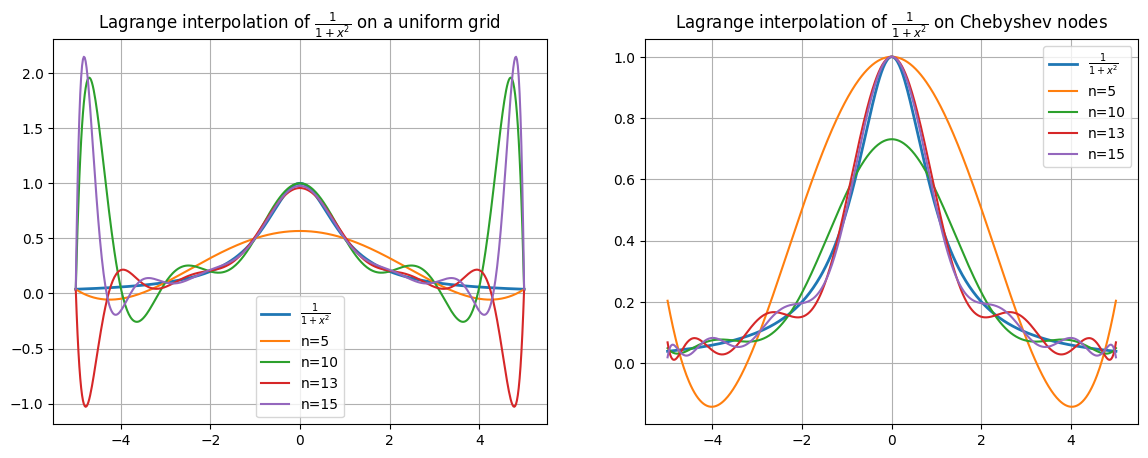

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(x, f(x), label=r"$\frac{1}{1+x^2}$", linewidth=2)

for n in ns:
    x_nodes = np.linspace(-5, 5, n+1)
    f_values = f(x_nodes)
    f_L = L(f_values, x_nodes)
    ax.plot(x, [f_L(xi) for xi in x], label=fr"n={n}")

ax.set_title(r"Lagrange interpolation of $\frac{1}{1+x^2}$ on a uniform grid")
ax.grid(True)
ax.legend()

ax = axes[1]
ax.plot(x, f(x), label=r"$\frac{1}{1+x^2}$", linewidth=2)

for n in ns:
    k = np.arange(n)
    x_nodes = 5 * np.cos((2*k+1)/(2*n) * np.pi)
    f_values = f(x_nodes)
    f_L = L(f_values, x_nodes)
    ax.plot(x, [f_L(xi) for xi in x], label=fr"n={n}")

ax.set_title(r"Lagrange interpolation of $\frac{1}{1+x^2}$ on Chebyshev nodes")
ax.grid(True)
ax.legend()


plt.show()

Интерполяция Лагранжа функции $f(x)=\frac{1}{1+x^2}$ на равномерной сетке численно расходится (осцилляции на концах) $-$ феномен Рунге. Подавляется сменой сетки на узлы Чебышева: ошибка интерполяции равномерно убывает.
Для отрезка $[-L, L]$ узлы Чебышева:
$$x_k = L\,\cos \left(\frac{2k+1}{2(n+1)}\,\pi\right),
\quad k=0,\dots,n.$$

На краях
$$|R_n(x)|= \left|\frac{f^{(n+1)}(\xi)}{(n+1)!}\,\Omega_n(x)\right| \rightarrow \infty.$$

Без доказательства.

###Интерполяция гауссианы

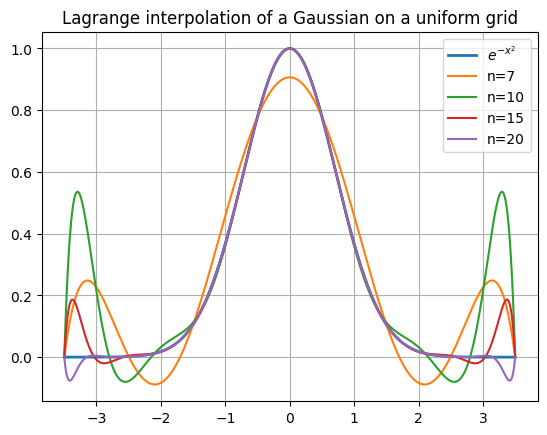

In [ ]:
f_gaussian = lambda x: np.exp(-x**2)
x = np.linspace(-3.5, 3.5, 1000)
ns = [7, 10, 15, 20]

plt.plot(x, f_gaussian(x), label=r"$e^{-x^2}$", linewidth=2)

for n in ns:
    x_nodes = np.linspace(-3.5, 3.5, n+1)
    f_values = f_gaussian(x_nodes)
    f_L = L(f_values, x_nodes)
    plt.plot(x, [f_L(xi) for xi in x], label=fr"n={n}")

plt.title("Lagrange interpolation of a Gaussian on a uniform grid")
plt.grid(True)
plt.legend()
plt.show()

Для оценки ошибки интерполяции требуется в частности оценить $n$-ую производную гауссианы. Имеем знание, что $$H_n(x)=(-1)^ne^{x^2}\frac{d^n}{dx^n}e^{-x^2},$$
$H_n(x)$ – полином Эрмита.

Значит,
$$\frac{d^n}{dx^n}e^{-x^2} = (-1)^nH_n(x)e^{-x^2} \Rightarrow \left|\frac{d^n}{dx^n}e^{-x^2}\right|=|H_n(x)|e^{-x^2}.$$

Асимптотика полиномов Эрмита в ненулевых точках:
$$H_n(x) \sim 2^nx^n\exp\left(-\frac{n^2}{4x^2}\right).$$

Суммируя факты:
$$R_n(x) = \frac{\left(e^{-x^2}\right)^{(n+1)}(\xi)}{(n+1)!}\Omega_n(x) < \frac{2^{n+1}x^{n+1}}{(n+1)!}\exp\left(-\frac{(n+1)^2}{4\xi^2}\right)(2L)^{n+1}.$$
Здесь также было использовано, что $\Omega_n(x) = (x-x_0)\cdots (x-x_n) < (2L)^{n+1}$, рассматривается поведение на $[-L, L]$.

С учетом формулы Стирлинга:
$$|R_n(x)| < \frac{(4Lx)^{\,n+1}}{(n+1)!}
\exp\!\left(-\frac{(n+1)^2}{4\xi^2}\right)
\;\sim\;
\frac{1}{\sqrt{2\pi(n+1)}}
\left(\frac{4eLx}{\,n+1\,}\right)^{n+1}
\exp\!\left(-\frac{(n+1)^2}{4\xi^2}\right) \\ \Rightarrow R_n(x)\rightarrow 0.$$

Теоретические ожидания - численная сходимость. Результаты на графике согласуются с этим.

##Интерполяция спалайнами


Функция ``solve_M(x_nodes, y_values, M_left=0.0, M_right=0.0)`` принимает на вход массив узлов ``x_nodes``, массив значений функции в этих узлах ``y_values`` и граничные условия на вторые производные ``M_left``, ``M_right``. Результат работы – массив вторых производных кубического сплайна $S(x)$ в узловых точках:
$$M_i = S_i''(x_i).
$$

Значения вторых производных $M_i$ находятся из системы уравнений:
$$
\frac{h_i}{6} M_{i-1}
\;+\;
\frac{h_i + h_{i+1}}{3} M_i
\;+\;
\frac{h_{i+1}}{6} M_{i+1}
\;=\;
\frac{y_{i+1} - y_i}{h_{i+1}}
\;-\;
\frac{y_i - y_{i-1}}{h_i},
$$
где $h_i = x_i-x_{i-1}.$

Функция ``solve_M(x_nodes, y_values, M_left=0.0, M_right=0.0)`` реализует метод прогонки для данной системы. Очевидно, соответствующая матрица является диагонально преобладающей.

In [ ]:
def solve_M(x_nodes, y_values, M_left=0.0, M_right=0.0):
    n = len(x_nodes) - 1
    h = np.diff(x_nodes)
    M = np.zeros(n+1)

    A = h[:-1] / 6
    B = (h[:-1] + h[1:]) / 3
    C = h[1:] / 6
    F = (y_values[2:] -  y_values[1:-1]) / h[1:] - (y_values[1:-1] -  y_values[:-2]) / h[:-1]

    for i in range(1, n-1):
        coef = A[i-1] / B[i-1]
        B[i] -= coef * C[i-1]
        F[i] -= coef * F[i-1]

    M[n-1] = F[-1] / B[-1]

    for i in range(n-2, -1, -1):
        M[i+1] = (F[i] - C[i] * M[i+2]) / B[i]

    M[0] = M_left
    M[n] = M_right

    return M

Функция ``S_i(i, x_nodes, y_values, M)`` находит $S_i(x)$ многочлен на отрезке $[x_{i-1}, x_i]$, принимает на вход номер отрезка ``i``, массив узлов ``x_nodes``, массив значений функции в узлах ``y_values``, массив вторых производных ``M`` кубического сплайна в узлах.

$$S_i(x) =
\frac{y_{i-1}}{h_i}(x_i - x)
+ \frac{y_i}{h_i}(x - x_{i-1})
+ M_{i-1}\!\left(
    \frac{(x_i - x)^3}{6 h_i}
    - \frac{h_i (x_i - x)}{6}
\right)
+ M_i\!\left(
    \frac{(x - x_{i-1})^3}{6 h_i}
    - \frac{h_i (x - x_{i-1})}{6}
\right)$$

Функция ``S(x_nodes, y_values, M)`` "склеивает" многочлены на отрезках. Результатом является искомый кубический сплайн $S(x)$ ``<class 'function'>``.



In [ ]:
def S_i(i, x_nodes, y_values, M):
    h_i = x_nodes[i] - x_nodes[i-1]

    return lambda x: (
        y_values[i-1] / h_i * (x_nodes[i] - x)
        + y_values[i]   / h_i * (x - x_nodes[i-1])
        + M[i-1] * ( (x_nodes[i] - x)**3 / (6 * h_i) - h_i * (x_nodes[i] - x) / 6 )
        + M[i]  * ( (x - x_nodes[i-1])**3 / (6 * h_i) - h_i * (x - x_nodes[i-1]) / 6 )
    )

def S(x_nodes, y_values, M):
    n = len(x_nodes) - 1
    S_total = [S_i(i, x_nodes, y_values, M) for i in range(1, n+1)]

    def spline(x):
        i = np.searchsorted(x_nodes, x, side='right') - 1
        i = int(np.clip(i, 0, n-1))
        return S_total[i](x)

    return spline

###Интерполяция кубическими спланами на примере функции $\frac{1}{1+x^2}$ и гауссианы при естественных условиях $M_0=M_n=0$

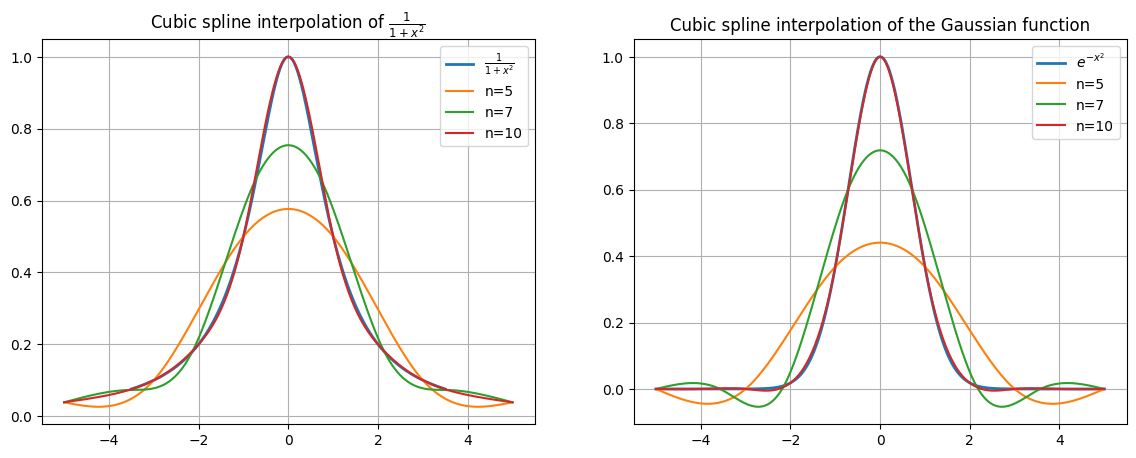

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(x, f(x), label=r"$\frac{1}{1+x^2}$", linewidth=2)

x = np.linspace(-5, 5, 500)
ns = [5, 7, 10]

for n in ns:
    x_nodes = np.linspace(-5, 5, n+1)
    f_values = f(x_nodes)
    M = solve_M(x_nodes, f_values)
    f_L = S(x_nodes, f_values, M)
    ax.plot(x, [f_L(xi) for xi in x], label=fr"n={n}")

ax.set_title(r"Cubic spline interpolation of $\frac{1}{1+x^2}$")
ax.grid(True)
ax.legend()

ax = axes[1]
ax.plot(x, f_gaussian(x), label=r"$e^{-x^2}$", linewidth=2)

for n in ns:
    x_nodes = np.linspace(-5, 5, n+1)
    f_values = f_gaussian(x_nodes)
    M = solve_M(x_nodes, f_values)
    f_L = S(x_nodes, f_values, M)
    ax.plot(x, [f_L(xi) for xi in x], label=fr"n={n}")

ax.set_title("Cubic spline interpolation of the Gaussian function")
ax.grid(True)
ax.legend()


plt.show()

Предсказуемый результат. Осцилляций на краях больше нет.

###Интерполяция кубическими спланами функции $\frac{1}{1+x^2}$ при разных граничных значениях вторых производных

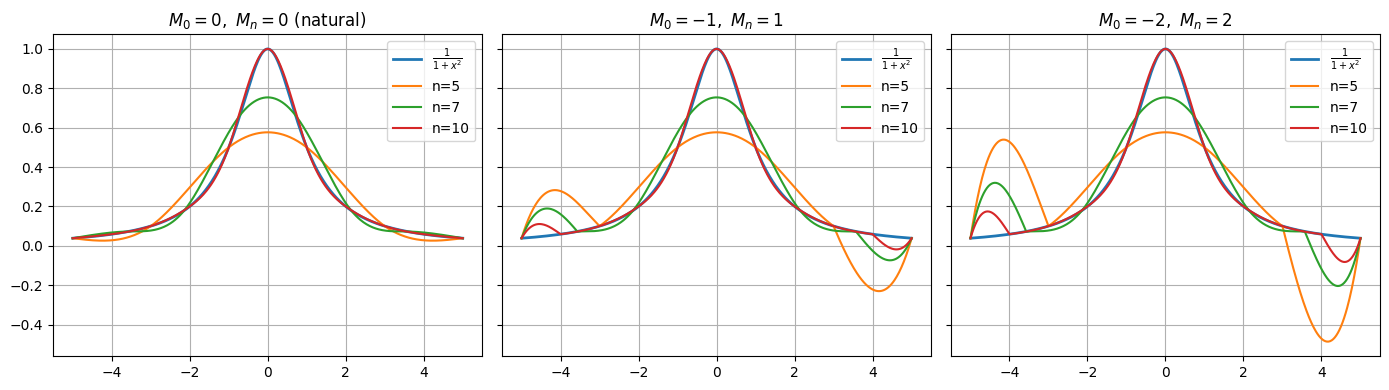

In [ ]:
x = np.linspace(-5, 5, 500)
ns = [5, 7, 10]

boundary_cases = [
    (0.0, 0.0, r"$M_0 = 0,\ M_n = 0$ (natural)"),
    (-1.0, 1.0, r"$M_0 = -1,\ M_n = 1$"),
    (-2.0, 2.0, r"$M_0 = -2,\ M_n = 2$"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (M_left, M_right, label) in zip(axes, boundary_cases):

    ax.plot(x, f(x), label=r"$\frac{1}{1+x^2}$", linewidth=2)

    for n in ns:
        x_nodes = np.linspace(-5, 5, n+1)
        f_values = f(x_nodes)
        M = solve_M(x_nodes, f_values, M_left=M_left, M_right=M_right)
        f_L = S(x_nodes, f_values, M)
        ax.plot(x, [f_L(xi) for xi in x], label=fr"n={n}")

    ax.set_title(label)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

Предсказуемый результат. При изменении граничных значений вторых производных край графика соответственно "подлетает" вниз или вверх (в зависимости от знака второй производной). Учитывая интерполяцию сплайнами, края "независимы".

#Численное дифференцирование

Рассмотрим равноудаленные узлы $(x_0, x_1, x_2, x_3, x_4)$, в которых значение функции соответственно $f_0, f_1, f_2, f_3, f_4$.

Разделенные разности:
$$
\begin{aligned}
f&[x_0,x_1] = \frac{f_1 - f_0}{h},\\[6pt]
f&[x_0,x_1,x_2] = \frac{f_2 - 2f_1 + f_0}{2h^2},\\[6pt]
f&[x_0,x_1,x_2,x_3] = \frac{f_3 - 3f_2 + 3f_1 - f_0}{6h^3},\\[6pt]
f&[x_0,x_1,x_2,x_3,x_4] =\frac{f_4-4f_3+6f_2-4f_1+f_0}{24\,h^4}
\end{aligned}
$$

Интерполяционный многочлен Ньютона и его производная:
$$
\begin{aligned}
L_n(x)
&=
\sum_{k=0}^{n}
f[x_0,\dots,x_k]
\prod_{i=0}^{k-1}(x-x_i), \\
L_n'(x)
&=
\sum_{k=1}^{n}
f[x_0,\dots,x_k]
\sum_{j=0}^{k-1}
\prod_{\substack{i=0\\ i\neq j}}^{k-1}(x-x_i).
\end{aligned}
$$

Эта запись производной очевидно следует из правила Лейбница.

## Дифференцирование по четырем равноудалённым точкам $(x_0, x_1, x_2, x_3)$ для первой, второй и третьей производной в $x_0$

Аппроксимируем производную функции в точке $x_0$ производной
интерполяционного многочлена:
$$f^{(n)}(x_0) \approx L^{(n)}(x_0).$$

Первая производная:
$$
\begin{aligned}
L_3(x) &= f[x_0,x_1]
+ f[x_0,x_1,x_2]\big((x-x_0)+(x-x_1)\big)\\
&+ f[x_0,x_1,x_2,x_3]\big(
(x-x_1)(x-x_2)
+(x-x_0)(x-x_2)
+(x-x_0)(x-x_1)
\big) \\ \Rightarrow
L_3'(x_0)&=f[x_0,x_1]
+ f[x_0,x_1,x_2](x_0-x_1)
+ f[x_0,x_1,x_2,x_3](x_0-x_1)(x_0-x_2)\\ \Rightarrow L_3'(x_0) &= \frac{f_1 - f_0}{h} - \frac{f_2 - 2f_1 + f_0}{2h^2}h+\frac{f_3 - 3f_2 + 3f_1 - f_0}{6h^3}h\cdot2h \\ \Rightarrow f'(x_0) &\approx L_3'(x_0) = \frac{-11f_0+18f_1-9f_2+2f_3}{6h}
\end{aligned}
$$

Вторая производная:
$$
\begin{aligned}
L_3''(x)
&=
2\,f[x_0,x_1,x_2]
+2\,f[x_0,x_1,x_2,x_3]
\big((x-x_0)+(x-x_1)+(x-x_2)\big),\\[6pt]
\Rightarrow L_3''(x_0)
&=
2\,f[x_0,x_1,x_2]
-6h\,f[x_0,x_1,x_2,x_3],\\[6pt]
\Rightarrow f''(x_0)
&\approx L_3''(x_0)
=
\frac{2f_0-5f_1+4f_2-f_3}{h^2}.
\end{aligned}
$$

Третья производная:
$$
\begin{aligned}
L_3^{(3)}(x)
&= 6\,f[x_0,x_1,x_2,x_3]\\[6pt]
\Rightarrow\quad
f^{(3)}(x_0)
&\approx L_3^{(3)}(x_0)
= \frac{-f_0+3f_1-3f_2+f_3}{h^3}.
\end{aligned}
$$

### Реализация

Ввод полиномов $p_k(x)=x^k,\, k \in \{1, 2, 3, 4\}$ и их производных.

In [ ]:
p  = [lambda x: x,
      lambda x: x**2,
      lambda x: x**3,
      lambda x: x**4]

dp = [lambda x: 1,
      lambda x: 2*x,
      lambda x: 3*x**2,
      lambda x: 4*x**3]

d2p = [lambda x: 0,
       lambda x: 2,
       lambda x: 6*x,
       lambda x: 12*x**2]

d3p = [lambda x: 0,
       lambda x: 0,
       lambda x: 6,
       lambda x: 24*x]

Для каждого полинома требуется построить графики ошибок производных в зависимости от $h$.

Функция ``approximation_error(f, df, d2f, d3f, x0, h_arr)`` принимает функцию и ее первые три производные ``f``, ``df``, ``d2f``, ``d3f``, первый узел сетки ``x_0`` и массив шагов сетки ``h_arr``. Результат работы $-$ матрица ошибок размера $(3, 13)$, в первой строчке ошибки для первой производной и тп.

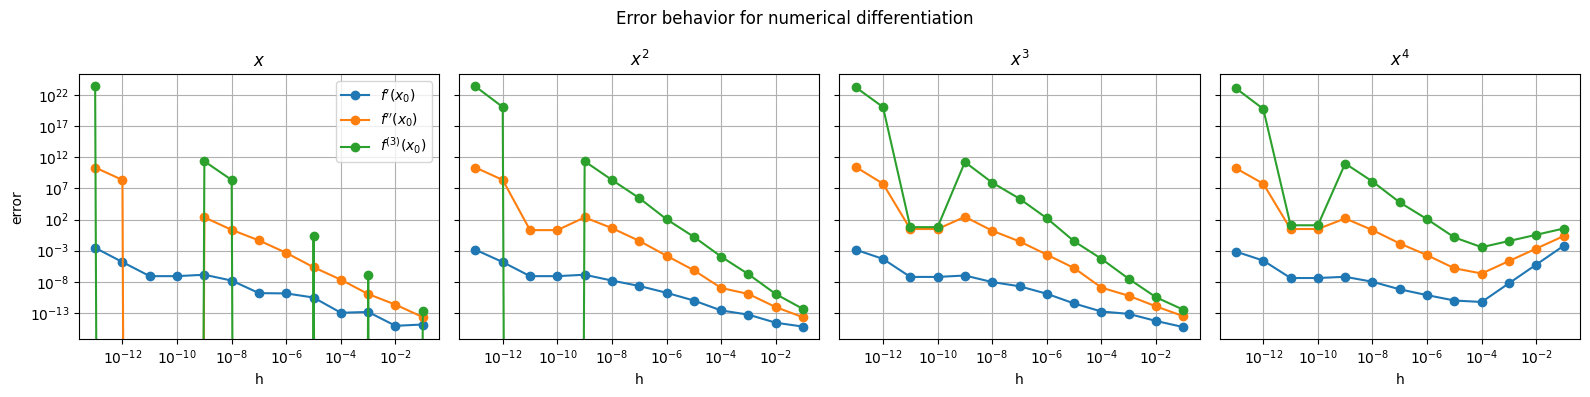

In [ ]:
def approximation_error(f, df, d2f, d3f, x0, h_arr):
  f0, f1, f2, f3 = np.array([[f(x0), f(x0 + h), f(x0 + 2*h), f(x0 + 3*h)] for h in h_arr]).T

  err1 = np.abs((-11*f0 + 18*f1 - 9*f2 + 2*f3)/(6*h_arr) - df(x0))
  err2 = np.abs((2*f0 - 5*f1 + 4*f2 - f3)/(h_arr**2) - d2f(x0))
  err3 = np.abs((-f0 + 3*f1 - 3*f2 + f3)/(h_arr**3) - d3f(x0))

  return np.array([err1, err2, err3])

x0 = 0.5
h_arr = np.logspace(-1, -13, 13)

errors = np.array([approximation_error(p[k], dp[k], d2p[k], d3p[k], x0, h_arr) for k in range(4)])

#print(np.shape(errors[0]))

poly_titles = [r"$x$", r"$x^2$", r"$x^3$", r"$x^4$"]
deriv_titles = [r"$f'(x_0)$", r"$f''(x_0)$", r"$f^{(3)}(x_0)$"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for p in range(4):
    for d in range(3):
        axes[p].loglog(
            h_arr,
            errors[p][d],
            marker='o',
            label=deriv_titles[d]
        )

    axes[p].set_title(poly_titles[p])
    axes[p].set_xlabel("h")
    axes[p].grid(True, which="both")

axes[0].set_ylabel("error")
axes[0].legend()

fig.suptitle("Error behavior for numerical differentiation")
plt.tight_layout()
plt.show()

Рассуждения на тему возрастания ошибки при уменьшении шага $h$ представлены ниже.

##Дифференцирование по пяти точкам

Вторая производная по пяти точкам:
$$f''(x_0)\;\approx \frac{35f_0-104f_1+114f_2-56f_3+11f_4}{12h^2}$$

*Remark: действия происходят на равномерной сетке с шагом $h$ $[x_k = x_0 +kh]$*

Эта формула может быть получена из приближения $f''(x_0)\approx L_4''(x_0)$ или через метод неопределенных коэффициентов. Первый вариант был описан ранее, поэтому далее рассмотривается второй.

По предположению:
$$f''(x_0) \approx \alpha_0 f_0 + \alpha_1 f_1 + \alpha_2f_2 + \alpha_3 f_3+\alpha_4 f_4.$$

Это разложение должно быть справделиво для полиномов $p_k(x) = (x-x_0)^k$ при $k \in \{0, \dots, 4\}.$ Из этого следует система на $\alpha$:

$$
\begin{cases}
\sum\limits_{k=0}^4 \alpha_k=0\\
\sum\limits_{k=1}^4 k\alpha_k=0\\
\sum\limits_{k=1}^4 k^2\alpha_k= \frac{2}{h^2}\\
\sum\limits_{k=1}^4 k^3\alpha_k=0\\
\sum\limits_{k=1}^4 k^4\alpha_k=0
\end{cases} \Rightarrow \begin{cases}
\alpha_0 + \alpha_1+\alpha_2+\alpha_3+\alpha_4 = 0\\
\alpha_1+2\alpha_2+3\alpha_3+4\alpha_4 = 0\\
\alpha_1+4\alpha_2+9\alpha_3+16\alpha_4 = \frac{2}{h^2}\\
\alpha_1+8\alpha_2+27\alpha_3+64\alpha_4 = 0\\
\alpha_1+16\alpha_2+81\alpha_3+256\alpha_4 = 0
\end{cases}
$$

Решение системы:
$$
\alpha_0=\frac{35}{12},\quad
\alpha_1=-\frac{26}{3},\quad
\alpha_2=\frac{19}{2},\quad
\alpha_3=-\frac{14}{3},\quad
\alpha_4=\frac{11}{12}.
$$

###Оценка модуля ошибки $R_4''(x)$

Функция представляется в виде:
$$f(x) = L_4(x) + R_4(x).$$
Значит, $$f''(x) = L_4''(x) + R_4''(x).$$

$R_4''(x)$ – искомая ошибка, абсолютное значение которой требуется оценить.

Остаток модуля интерполяции $R_4(x)$ можно записать через разделенную разность:
$$R_4(x) = f[x, x_0,\dots, x_4]\Omega_4(x),$$
где $\Omega_n(x) = \prod\limits_{i=1}^n(x-x_i).$

Тогда
$$R_4''(x) = \frac{d^2}{dx^2}f[x,x_0,\dots,x_4]\cdot \Omega_4(x)+2\frac{d}{dx}f[x,x_0,\dots,x_4]\cdot \Omega_4'(x) + f[x,x_0,\dots,x_4]\cdot\Omega_4''(x)\\=2f[x,x,x,x_0,\dots,x_4]\cdot\Omega_4(x)+2f[x,x,x_0,\dots,x_4]\cdot\Omega_4'(x) + f[x,x_0,\dots,x_4]\cdot\Omega_4''(x)\\ = 2\frac{f^{(6)}(\xi_1)}{6!}\Omega_4(x)+2\frac{f^{(5)}(\xi_2)}{5!}\Omega_4'(x)+\frac{f^{(4)}(\xi_3)}{4!}\Omega_4''(x)\\
\Rightarrow |R_4''(x)| \leq \frac{2}{6!}\left|f^{(6)}(\xi_1)\right|\cdot|\Omega_4(x)|+\frac{2}{5!}\left|f^{(5)}(\xi_2)\right|\cdot|\Omega_4'(x)|+\frac{1}{4!}\left|f^{(4)}(\xi_3)\right|\cdot|\Omega_4''(x)|.$$

В точке $x_0$:
$$\Omega_4(x_0) = 0, \quad \Omega_4'(x_0) = 4!\,h^4, \quad \Omega_4''(x_0) = -100h^3.$$

Оценка $|R_4''(x_0)|$:
$$|R_4''(x_0)| \leq \frac{2}{5}\left|f^{(5)}(\xi_2)\right|h^4+\frac{25}{6}\left|f^{(4)}(\xi_3)\right|h^3 \\ \Rightarrow |R_4''(x_0)| \leq \frac{2}{5}h^4\sup\limits_{[x_0, x_4]}|f^{(5)}(\xi)|+\frac{25}{6}h^3\sup\limits_{[x_0, x_4]}|f^{(4)}(\xi)|$$

Учитывая задание далее, положим, что $\forall k: \left|\sup\limits_{[x_0, x_4]}|f^{(k)}(\xi)|\right| \leq M,$ тогда

$$|R_4''(x_0)| \leq \frac{2}{5}Mh^4+\frac{25}{6}Mh^3.$$


Функция ``d2_five_point(f, d2f, x0, h_arr)`` вычисляет абсолютные значения ошибок второй производной функции ``f`` (найденной по пяти точкам). Принимает первый узел сетки ``x_0``, массив шагов ``h_arr``, функцию ``f`` и ее вторую производную ``df``.

``bound_arr(h_arr)`` принимает ``h_arr``, выводит массив оценок ошибки.

Рассматривается функция $f(x)=\sin(x)$. Очевидно, $M=1$.

Требуется построить график фактической ошибки и теоретической оценки этой ошибки в зависимости от $h$.

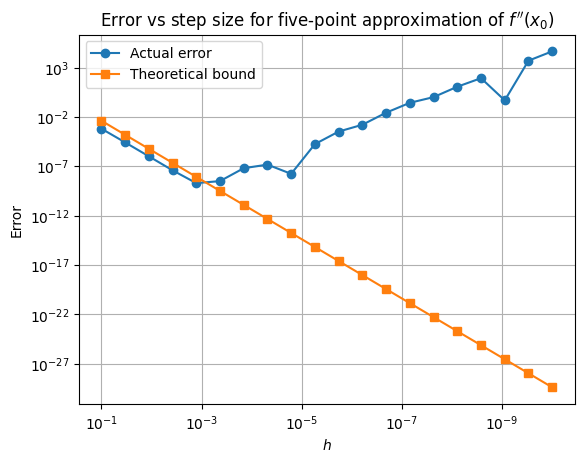

In [ ]:
f   = lambda x: np.sin(x)
d2f = lambda x: -np.sin(x)

def d2_five_point(f, d2f, x0, h_arr):
    f0, f1, f2, f3, f4 = np.array([[f(x0), f(x0 + h), f(x0 + 2*h), f(x0 + 3*h), f(x0+4*h)] for h in h_arr]).T
    d2 = (35*f0 - 104*f1 + 114*f2 - 56*f3 + 11*f4) / (12*h_arr**2)
    d = (35*f0 - 104*f1 + 114*f2 - 56*f3 + 11*f4)
    err = np.abs(d2-d2f(x0))
    return err

def bound_arr(h_arr):
  return 2/5 * h_arr**4 + 25/6 * h_arr**3

x0 = 0.5
h_arr = np.logspace(-1, -10, 20)

err = d2_five_point(f, d2f, x0, h_arr)
bound = bound_arr(h_arr)

plt.figure()
plt.loglog(h_arr, err, marker='o', label='Actual error')
plt.loglog(h_arr, bound, marker='s', label='Theoretical bound')
plt.gca().invert_xaxis()
plt.xlabel(r'$h$')
plt.ylabel('Error')
plt.title('Error vs step size for five-point approximation of $f\'\'(x_0)$')
plt.grid(True, which='both')
plt.legend()
plt.show()

Заметим, что $$|R_4''(x_0)| \leq \frac{2}{5}Mh^4+\frac{25}{6}Mh^3 \underset{h\to 0}{\longrightarrow}
 0.$$
Значит, в теории, при $h \rightarrow 0$ ошибка уменьшается.

Также заметим, что
$$f_1 \underset{h\to 0}{\longrightarrow} f_0, \quad f_2 \underset{h\to 0}{\longrightarrow} f_0, \quad f_3 \underset{h\to 0}{\longrightarrow} f_0, \quad f_4 \underset{h\to 0}{\longrightarrow} f_0.$$

Пусть $f_k = f_0 + \varepsilon_k, k \in \{1, 2, 3, 4\}.$ Тогда
$$f''(x_0) \approx \frac{35f_0-104f_1+114f_2-56f_3+11f_4}{12h^2} = \frac{35\varepsilon_0-104\varepsilon_1+114\varepsilon_2-56\varepsilon_3+11\varepsilon_4}{12h^2} = \frac{\varepsilon}{h^2}.$$

Фактическая ошибка возрвастает из-за конечной точности машинных вычислений, проблемы с вычислением $\varepsilon$, ошибка возрастает как $\sim h^{-2}$.

#Численное интегрирование

##Метод прямоугольников

Функция ``rectangle_method(func, a, b, n, method)`` реализует метод прямоугольников на равномерной сетке. Принимает на вход интегрируемую функцию ``func``, пределы интегрирования ``a`` и ``b``, количество разбиений ``n`` и тип метода ``method`` ``('left', 'right' или 'middle')``.

Для метода средних прямоугольников ``'middle'`` вычисление происходит по формуле:
$$ \int\limits_a^b f(x)dx  \approx h \sum_{i=0}^{n-1} f\left(a + \left(i + 0.5\right)h\right), \quad \text{где } h = \frac{b-a}{n} $$

In [ ]:
def rectangle_method(func, a, b, n, method='middle'):
    h = (b - a) / n
    result = 0.0

    for i in range(n):
        if method == 'left':
            x = a + i * h
        elif method == 'right':
            x = a + (i + 1) * h
        else: # middle
            x = a + (i + 0.5) * h

        result += func(x)

    return result * h

##Метод трапеций

Функция ``trapezoidal_method(func, a, b, n)`` реализует метод трапеций. Принимает на вход функцию ``func``, границы отрезка ``a``, ``b`` и число шагов ``n``.

Формула вычисления:
$$ \int\limits_a^b f(x)dx\approx \frac{h}{2} \left( f(a) + f(b) + 2\sum_{i=1}^{n-1} f(a + i  h) \right) .$$

In [ ]:
def trapezoidal_method(func, a, b, n):
    h = (b - a) / n
    result = 0.5 * (func(a) + func(b))
    for i in range(1, n):
        result += func(a + i * h)

    return result * h


##Метод Симпсона (парабол)

Функция ``simpson_method(func, a, b, n)`` вычисляет интеграл методом парабол. Принимает те же аргументы, но требует, чтобы ``n`` было четным (корректируется внутри функции при необходимости).

Вычисление производится по формуле с группировкой четных и нечетных узлов:
$$ \int\limits_a^b f(x)dx \approx \frac{h}{3} \left[ f(a) + f(b) + 4\sum_{i=1, 3, \dots}^{n-1} f(x_i) + 2\sum_{i=2, 4, \dots}^{n-2} f(x_i) \right]. $$

In [ ]:
def simpson_method(func, a, b, n):
    if n % 2 != 0:
        raise ValueError("Для метода Симпсона n должно быть четным!")

    h = (b - a) / n
    result = func(a) + func(b)

    for i in range(1, n):
        x = a + i * h
        if i % 2 != 0:
            result += 4 * func(x)
        else:
            result += 2 * func(x)

    return result * (h / 3)

## Метод Симпсона 3/8

Функция ``simpson_38_method(func, a, b, n)`` реализует правило 3/8. Требует, чтобы количество разбиений ``n`` было кратно 3.

Формула вычисления:
$$ I \approx \frac{3h}{8} \left[ f(a) + f(b) + 3\sum_{i \not\equiv 0 (\text{mod } 3)} f(x_i) + 2\sum_{i \equiv 0 (\text{mod } 3), i \neq n} f(x_i) \right] $$

In [ ]:
def simpson_38_method(func, a, b, n):
    if n % 3 != 0:
        raise ValueError("Для метода 3/8 n должно быть кратно 3!")

    h = (b - a) / n
    result = func(a) + func(b)

    for i in range(1, n):
        x = a + i * h
        if i % 3 == 0:
            result += 2 * func(x)
        else:
            result += 3 * func(x)

    return result * (3 * h / 8)


##Работа методов на функциях $x^3, e^x, \sin(x)$

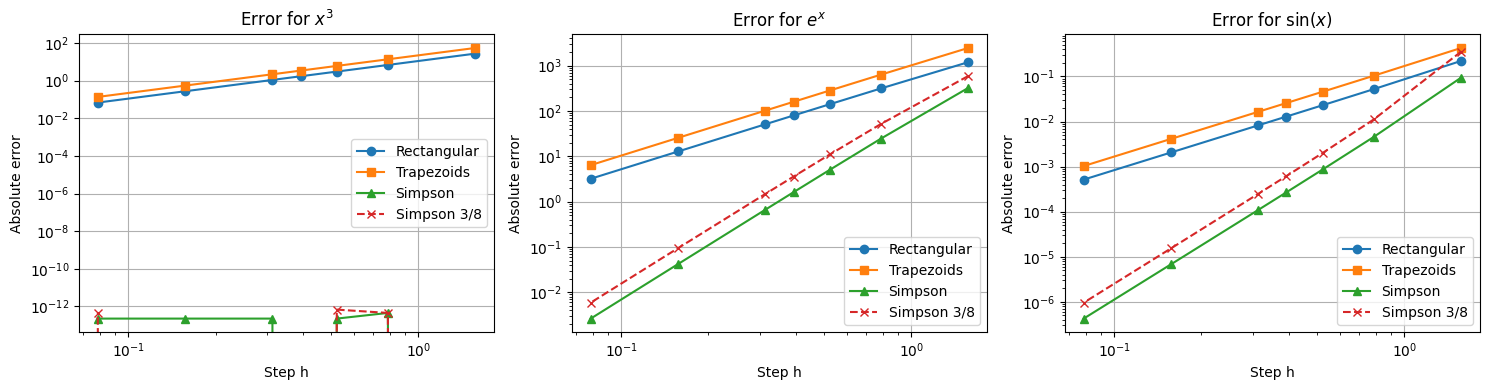

In [ ]:
if __name__ == "__main__":
    functions = [
        {"f": lambda x: x**3, "name": r"$x^3$", "int": lambda a, b: (b**4 - a**4)/4},
        {"f": np.exp,         "name": r"$e^x$",  "int": lambda a, b: np.exp(b) - np.exp(a)},
        {"f": np.sin,         "name": r"$\sin(x)$", "int": lambda a, b: -np.cos(b) + np.cos(a)}
    ]


    a, b = 0, 3*np.pi
    steps = [6, 12, 18, 24, 30, 60, 120]

    plt.figure(figsize=(15, 4))

    for idx, item in enumerate(functions):
        f = item["f"]
        name = item["name"]
        exact_val = item["int"](a, b)

        h_vals = []
        err_rect, err_trap, err_simp, err_38 = [], [], [], []

        for n in steps:
            h = (b - a) / n
            h_vals.append(h)

            val_r = rectangle_method(f, a, b, n)
            val_t = trapezoidal_method(f, a, b, n)
            val_s = simpson_method(f, a, b, n)
            val_3 = simpson_38_method(f, a, b, n)

            err_rect.append(abs(val_r - exact_val))
            err_trap.append(abs(val_t - exact_val))
            err_simp.append(abs(val_s - exact_val))
            err_38.append(abs(val_3 - exact_val))


        plt.subplot(1, 3, idx + 1)

        plt.plot(h_vals, err_rect, 'o-', label='Rectangular')
        plt.plot(h_vals, err_trap, 's-', label='Trapezoids')
        plt.plot(h_vals, err_simp, '^-', label='Simpson')
        plt.plot(h_vals, err_38, 'x--', label='Simpson 3/8')

        plt.title(f'Error for {name}')
        plt.xscale('log')
        plt.yscale('log')
        plt.xlabel('Step h')
        plt.ylabel('Absolute error')
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()

1. Метод Симпсона точно интегрирует $x^3$ (т.к. четвертая производная равна нулю).

2. Скорость сходимости метода определяется как:
$$|I-I_h|\leq Ch^p,$$
где $p \,-$ порядок сходимости метода.
Для метода трапеций и (средних) прямоугольников $p = 2$, Симпсона $-$ $p=4$ (и для 1/3, и для 3/8). В логарифмических координатах$
(\log h,\ \log |I - I_h|)$ зависимость ошибки от шага является линейной и наклон прямой равен порядку
сходимости $p$.

3. Из графиков, наклон для метода Симпсона "круче" ($p$ больше) чем для метода трапеций или прямоугольников. Асимптотическая константа ошибки разделяет методы одного порядка. Так из графиков, $C_{1/3} < C_{3/8}$ и $C_\text{Rect} < C_\text{tr}$.

## Монте-Карло

Функция ``monte_carlo_integrate(func, a, b, n)`` вычисляет интеграл статистическим методом Монте-Карло. Принимает на вход функцию ``func``, границы интегрирования ``a`` и ``b`` и количество точек ``n``.

$$\int\limits_a^b f(x)dx = (b-a)\mathbf{E}_{\textrm{U}[a, b]}f(x) \approx (b-a)\frac{\sum\limits_{k=1}^nf(x_k)}{n}, \quad x_k \in \textrm{U}[a, b].$$

In [ ]:
def monte_carlo_integrate(func, a, b, n):
    x = np.random.uniform(a, b, n)
    return (b - a) * np.mean(func(x))

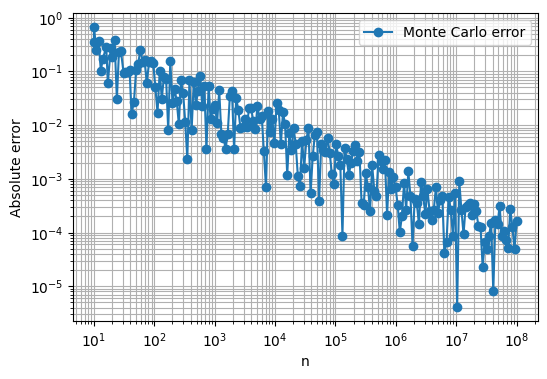

In [ ]:
func = np.sin
a, b = 0, np.pi

f = np.sin
a, b = 0.0, np.pi
exact = 2.0

n_vals = np.logspace(1, 8, 200, dtype=int)
errors = []

for n in n_vals:
    val = monte_carlo_integrate(f, a, b, n)
    errors.append(abs(val - exact))

plt.figure(figsize=(6, 4))
plt.loglog(n_vals, errors, 'o-', label='Monte Carlo error')
plt.xlabel('n')
plt.ylabel('Absolute error')
plt.grid(True, which='both')
plt.legend()
plt.show()



Метод Монте-Карло сходится по вероятности. На графике убывающий тренд ошибки.